# Import


In [1]:
import os

import numpy as np      
import pandas as pd                  
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras as keras  
import cv2 as cv   

from matplotlib.colors import ListedColormap

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

np.random.seed(42)
tf.random.set_seed(42)


2026-04-14 18:13:45.294770: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 18:13:45.304114: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-14 18:13:45.400618: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 18:13:45.400737: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 18:13:45.401059: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Hilfsfunktionen


In [2]:
def transform_image(img, shift_x=0, shift_y=0, angle=0):
    h, w = img.shape
    M_shift = np.float32([[1, 0, shift_x],
                          [0, 1, shift_y]])
    shifted = cv.warpAffine(img, M_shift, (w, h))

    M_rot = cv.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    transformed = cv.warpAffine(shifted, M_rot, (w, h))

    return transformed


def augment_dataset(x, y, shift_x=3, shift_y=3, angle=15):
    augmented_imgs   = []
    augmented_labels = []

    for img, label in zip(x, y):
        variants = [
            transform_image(img, shift_x= shift_x, shift_y=0,        angle=0),
            transform_image(img, shift_x=-shift_x, shift_y=0,        angle=0),
            transform_image(img, shift_x=0,        shift_y= shift_y, angle=0),
            transform_image(img, shift_x=0,        shift_y=-shift_y, angle=0),
            transform_image(img, shift_x=0,        shift_y=0,        angle= angle),
            transform_image(img, shift_x=0,        shift_y=0,        angle=-angle),
        ]
        augmented_imgs.extend(variants)
        augmented_labels.extend([label] * len(variants))

    x_aug = np.array(augmented_imgs, dtype=x.dtype)
    y_aug = np.array(augmented_labels, dtype=y.dtype)

    return np.concatenate([x, x_aug]), np.concatenate([y, y_aug])


# 1. Daten laden und erkunden


Training Datenformat x: (60000, 28, 28)
Training Datenformat y: (60000,)
Training Datentyp x:        uint8
Training Datentyp y:        uint8
Training Werte y:           [0 1 2 3 4 5 6 7 8 9]
-------------------------------
Test Datenformat x:     (10000, 28, 28)
Test Datenformat y:     (10000,)
Test Datentyp x:        uint8
Test Datentyp y:        uint8
Test Werte y:           [0 1 2 3 4 5 6 7 8 9]


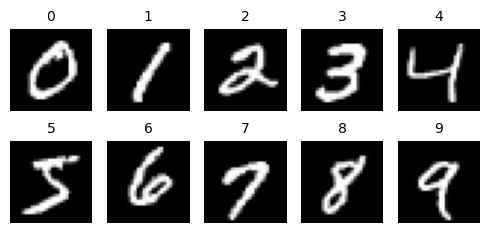

In [3]:

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training Datenformat x: {x_train.shape}")
print(f"Training Datenformat y: {y_train.shape}")
print(f"Training Datentyp x:        {x_train.dtype}")
print(f"Training Datentyp y:        {y_train.dtype}")
print(f"Training Werte y:           {np.unique(y_train)}")
print("-------------------------------")
print(f"Test Datenformat x:     {x_test.shape}")
print(f"Test Datenformat y:     {y_test.shape}")
print(f"Test Datentyp x:        {x_test.dtype}")
print(f"Test Datentyp y:        {y_test.dtype}")
print(f"Test Werte y:           {np.unique(y_test)}")

fig, axes = plt.subplots(2, 5, figsize=(5,2.5))

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(x_train[idx], cmap="gray")
    ax.set_title(str(digit), fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


Der Datensatz besteht aus 60.000 Trainings- und 10.000 Testdatensätzen.
Jeder Datensatz repräsentiert eine Ziffer (0–9) als 28×28 Pixelraster.


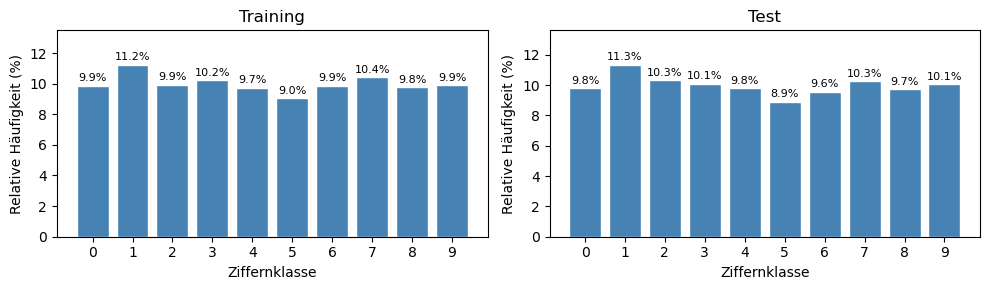

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

datasets = [
    (y_train, "Training"),
    (y_test,  "Test"),
]

for ax, (labels, title) in zip(axes, datasets):
    counts = np.bincount(labels, minlength=10)
    rel = counts / counts.sum()
    rel_pct = rel * 100
    classes = np.arange(10)

    bars = ax.bar(classes, rel_pct, color="steelblue", edgecolor="white")
    ax.set_xticks(classes)
    ax.set_xticklabels(classes)
    ax.set_xlabel("Ziffernklasse")
    ax.set_ylabel("Relative Häufigkeit (%)")
    ax.set_title(title)

    ax.set_ylim(0, rel_pct.max() * 1.20)

    for bar, pct in zip(bars, rel_pct):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()


Die Klassen sind gleichmäßig verteilt (~10 % pro Klasse).


# 2. Daten vorbereieten

Pixelwerte liegen in [0, 255] und werden von `uint8` zu `float32` konvertiert.
Mithilfe von Bildtransformationen werden mehrere leicht unterschiedliche Varianten der Datensätze simuliert.
Dieser Schritt ist auch als Daten Augmentation bekannt. Dadurch stehen nun zwei Datensätze zur Verfügung (Original vs Augmentiert).


In [5]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

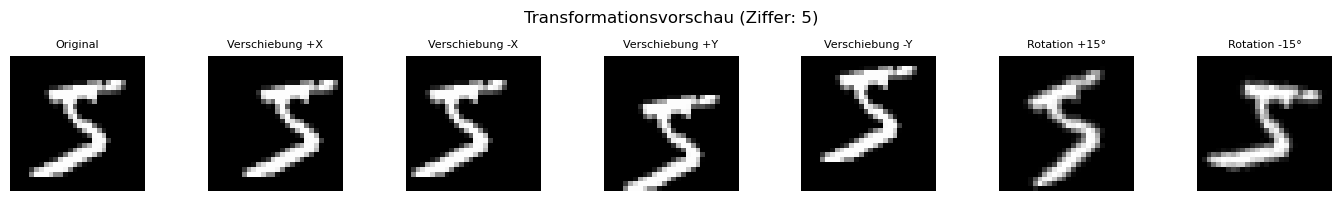

In [6]:

sample_img   = x_train[0]
sample_label = y_train[0]

variants = {
    "Original":         sample_img,
    "Verschiebung +X":         transform_image(sample_img, shift_x= 3),
    "Verschiebung -X":         transform_image(sample_img, shift_x=-3),
    "Verschiebung +Y":         transform_image(sample_img, shift_y= 3),
    "Verschiebung -Y":         transform_image(sample_img, shift_y=-3),
    "Rotation +15°":      transform_image(sample_img, angle= 15),
    "Rotation -15°":      transform_image(sample_img, angle=-15),
}

fig, axes = plt.subplots(1, len(variants), figsize=(14, 2))
fig.suptitle(f"Transformationsvorschau (Ziffer: {sample_label})", fontsize=12)
for ax, (title, img) in zip(axes, variants.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
x_train_aug, y_train_aug = augment_dataset(x_train, y_train, shift_x=3, shift_y=3, angle=15)

print(f"Ursprüngliche Anzahl Datensätze: {x_train.shape[0]}")
print(f"Augmentierte Anzahl Datensätze: {x_train_aug.shape[0]}")

Ursprüngliche Anzahl Datensätze: 60000
Augmentierte Anzahl Datensätze: 420000


## Normalisieren

Werte werden auf auf den Intervall [0,1] skaliert


In [8]:
normalized_0_1_x_train = x_train / 255.0
normalized_0_1_x_test  = x_test / 255.0

print(f"Intervall Training: [{normalized_0_1_x_train.min()}, {normalized_0_1_x_train.max()}]")
print(f"Intervall Test: [{normalized_0_1_x_test.min()},  {normalized_0_1_x_test.max()}]")

aug_normalized_0_1_x_train = x_train_aug / 255.0
aug_normalized_0_1_x_test  = normalized_0_1_x_test

datasets = {
    "Unverändert": (normalized_0_1_x_train, y_train, normalized_0_1_x_test, y_test),
    "Augmentiert": (aug_normalized_0_1_x_train, y_train_aug, aug_normalized_0_1_x_test, y_test),
}  

Intervall Training: [0.0, 1.0]
Intervall Test: [0.0,  1.0]


# 3. CNN erstellen und Training definieren


In [9]:
results_list = []

checkpoint_dir = "checkpoints"
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)


def create_cnn_model(add_dropout=False, dropout_rate=0.0, blocks=1):
    tf.keras.backend.clear_session()

    basic_layers = [keras.layers.Input(shape=(28, 28, 1))]
    for b in range(blocks):
        basic_layers += [
            keras.layers.Conv2D(filters=(b + 1) * 32, kernel_size=(3, 3), activation="relu"),
            keras.layers.MaxPooling2D(pool_size=(2, 2)),
        ]
    basic_layers += [keras.layers.Flatten()]

    dense_layers = [
        keras.layers.Dense(units=64, activation="relu"),
        *([keras.layers.Dropout(rate=dropout_rate)] if add_dropout else []),
        keras.layers.Dense(units=10, activation="softmax"),
    ]

    model = keras.Sequential(basic_layers + dense_layers)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_model_name(
    method, dataset_name, batch_size, epochs, add_dropout, dropout_rate, blocks, early_stop,
):
    safe_method = method.replace(" ", "_")
    safe_dataset = dataset_name.replace(" ", "_")
    dropout_value = str(dropout_rate).replace(".", "_")

    name_parts = [
        f"model_{safe_method}",
        safe_dataset,
        f"batch_{batch_size}",
        f"epochs_{epochs}",
        f"blocks_{blocks}",
        f"dropout_{dropout_value}" if add_dropout else "dropout_none",
        "earlystop" if early_stop else "noearlystop",
    ]
    return "_".join(name_parts) + ".keras"


def train_and_evaluate_models(
    datasets, method, batch_size=32, epochs=20, add_dropout=False,
    dropout_rate=0.0, blocks=1, early_stop=True,
):
    results = []
    histories = {}
    callbacks = []
    if early_stop:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=5, restore_best_weights=True
            )
        )

    for dataset_name, (data_x_train, data_y_train, data_x_test, data_y_test) in datasets.items():
        print(f"  Training: {dataset_name}")
        model = create_cnn_model(add_dropout=add_dropout, dropout_rate=dropout_rate, blocks=blocks)

        history = model.fit(
            data_x_train, data_y_train,
            batch_size=batch_size, epochs=epochs,
            validation_split=0.2, verbose=0,
            callbacks=callbacks,
        )
        test_loss, test_acc = model.evaluate(data_x_test, data_y_test, verbose=0)

        model_name = build_model_name(
            method=method,
            dataset_name=dataset_name,
            batch_size=batch_size,
            epochs=epochs,
            add_dropout=add_dropout,
            dropout_rate=dropout_rate,
            blocks=blocks,
            early_stop=early_stop,
        )
        model.save(os.path.join(checkpoint_dir, model_name))
        histories[dataset_name] = history

        results.append({
            "method": method,
            "dataset": dataset_name,
            "test_loss": float(test_loss),
            "test_acc": float(test_acc),
            "trained_epochs": len(history.history["loss"]),
            "best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
            "batch_size": batch_size,
            "epochs": epochs,
            "add_dropout": add_dropout,
            "dropout_rate": dropout_rate,
            "blocks": blocks,
            "early_stop": early_stop,
            "model_name": model_name,
        })

    results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
    results_list.append(results_df)
    return results_df, histories


def plot_metric_distribution_by_group(
    results_df,
    metric_col="test_acc",
    group_col="blocks",
    x_label_rotation=0,
    ylim=None,
):
    df_plot = results_df[[group_col, metric_col]].dropna().copy()
    df_plot[group_col] = df_plot[group_col].astype(str)
    df_plot = df_plot.sort_values(metric_col, ascending=True)

    labels = df_plot[group_col].tolist()
    values = df_plot[metric_col].tolist()
    best_val = max(values)

    colors = ["steelblue" if v < best_val else "seagreen" for v in values]

    fig, ax = plt.subplots(figsize=(8, max(3, len(labels) * 0.7)))
    bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.5)

    x_min = min(values) - 0.005 if ylim is None else ylim[0]
    x_max = 1.0 if ylim is None else ylim[1]
    ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.12)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + (x_max - x_min) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center", ha="left", fontsize=9,
        )

    ax.set_xlabel(metric_col)
    ax.set_ylabel(group_col)
    ax.set_title(f"{metric_col} by {group_col}")
    ax.tick_params(axis="x", labelrotation=x_label_rotation)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

---

# Phase 1 – Baseline

Ein einfaches Referenzmodell mit 1 Convolutional Block, ohne Dropout, Batch-Größe 32 und maximal 20 Epochen mit Early Stopping.
Trainiert wird auf der unveränderten, auf den Bereich [0,1] normalisierten Datenvariante.
Alle folgenden Phasen versuchen, diese Genauigkeit schrittweise zu übertreffen.


In [10]:
baseline_results, _ = train_and_evaluate_models(
    {"Unverändert": datasets["Unverändert"]},
    method="Baseline", batch_size=32, epochs=20, blocks=1, early_stop=True,
)

baseline_acc = baseline_results.iloc[0]["test_acc"]
print(f"\n→ Baseline accuracy (Unverändert, 1 Block, kein Dropout): {baseline_acc:.4f}")

  Training: Unverändert


2026-04-14 18:14:01.637933: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-14 18:14:01.927554: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



→ Baseline accuracy (Unverändert, 1 Block, kein Dropout): 0.9854


---

# Phase 2 – Beste Datengrundlage und Batch-Größe finden

Ausgehend von der Baseline werden zuerst die beiden Datenvarianten `Unverändert` und `Augmentiert` miteinander verglichen.
Beide Varianten basieren auf auf [0,1] normalisierten Bildern; der Unterschied liegt in der zusätzlichen Datenaugmentation im Training.
Anschließend werden für die bessere Datenvariante verschiedene Batch-Größen verglichen.
Das Ergebnis legt die Datenvariante und die Batch-Größe für die folgenden Phasen fest.


In [11]:
datasets_results, _ = train_and_evaluate_models(
    datasets,
    method="Dataset", batch_size=32, epochs=20, blocks=1, early_stop=True,
)


datasets_acc = datasets_results.iloc[0]["test_acc"]
print(f"\n→ Dataset accuracy (Block, kein Dropout): {datasets_acc:.4f}")

  Training: Unverändert
  Training: Augmentiert

→ Dataset accuracy (Block, kein Dropout): 0.9895


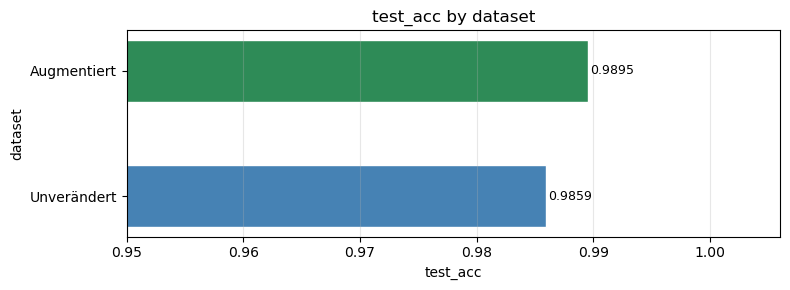


Beste Vorverarbeitungsvariante: Augmentiert (Test Accuracy: 0.9895)


In [12]:
plot_metric_distribution_by_group(
    datasets_results, metric_col="test_acc", group_col="dataset",
    x_label_rotation=0, ylim=(0.95, 1.0)
)

best_dataset = datasets_results.iloc[0]["dataset"]
best_dataset_acc = datasets_results.iloc[0]["test_acc"]

print(f"\nBeste Vorverarbeitungsvariante: {best_dataset} (Test Accuracy: {best_dataset_acc:.4f})")

  Training: Augmentiert
  Training: Augmentiert
  Training: Augmentiert
  Training: Augmentiert


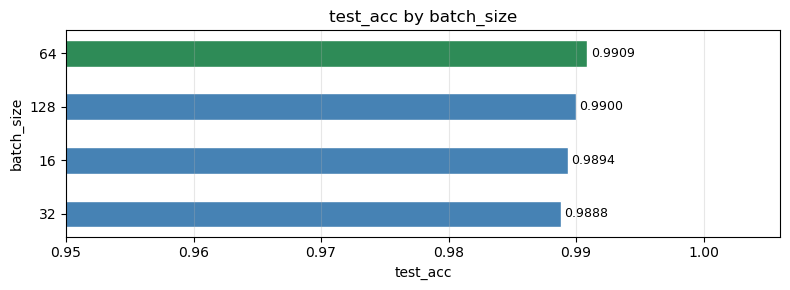


→ Beste Batch Size: 64 (Accuracy: 0.9909), Verbesserung zu Baseline %: 0.56%


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,epochs,add_dropout,dropout_rate,blocks,early_stop,model_name
0,Batch,Augmentiert,0.035929,0.9894,10,5,16,20,False,0.0,1,True,model_Batch_Augmentiert_batch_16_epochs_20_blo...
1,Batch,Augmentiert,0.039120,0.9888,10,5,32,20,False,0.0,1,True,model_Batch_Augmentiert_batch_32_epochs_20_blo...
2,Batch,Augmentiert,0.029700,0.9909,10,5,64,20,False,0.0,1,True,model_Batch_Augmentiert_batch_64_epochs_20_blo...
3,Batch,Augmentiert,0.031402,0.9900,10,5,128,20,False,0.0,1,True,model_Batch_Augmentiert_batch_128_epochs_20_bl...


In [13]:
batch_16_results, _ = train_and_evaluate_models(
    {best_dataset: datasets[best_dataset]},
    method="Batch", batch_size=16, epochs=20, early_stop=True, blocks=1,
)

batch_32_results, _ = train_and_evaluate_models(
    {best_dataset: datasets[best_dataset]},
    method="Batch", batch_size=32, epochs=20, early_stop=True, blocks=1,
)

batch_64_results, _ = train_and_evaluate_models(
    {best_dataset: datasets[best_dataset]},
    method="Batch", batch_size=64, epochs=20, early_stop=True, blocks=1,
)

batch_128_results, _ = train_and_evaluate_models(
    {best_dataset: datasets[best_dataset]},
    method="Batch", batch_size=128, epochs=20, early_stop=True, blocks=1,
)

batch_size_results = pd.concat([batch_16_results, batch_32_results, batch_64_results, batch_128_results], ignore_index=True)
best_batch_size = batch_size_results.loc[batch_size_results["test_acc"].idxmax(), "batch_size"]
best_batch_size_acc = batch_size_results["test_acc"].max()

plot_metric_distribution_by_group(
    batch_size_results, metric_col="test_acc", group_col="batch_size",
    x_label_rotation=0, ylim=(0.95, 1.0)
)

print(f"\n→ Beste Batch Size: {best_batch_size} (Accuracy: {best_batch_size_acc:.4f}), Verbesserung zu Baseline %: {(best_batch_size_acc - baseline_acc) / baseline_acc * 100:.2f}%")
batch_size_results

---

# Phase 3 – Beste Architektur finden (Anzahl der Blöcke)

Verwendet werden die beste Datenvariante und die beste Batch-Größe aus Phase 2, weiterhin ohne Dropout und mit maximal 20 Epochen sowie Early Stopping.
Verglichen werden 1, 2 und 3 Convolutional Blocks.
Das Ergebnis bestimmt die Blockanzahl für alle weiteren Phasen.


  Training: Augmentiert
  Training: Augmentiert
  Training: Augmentiert


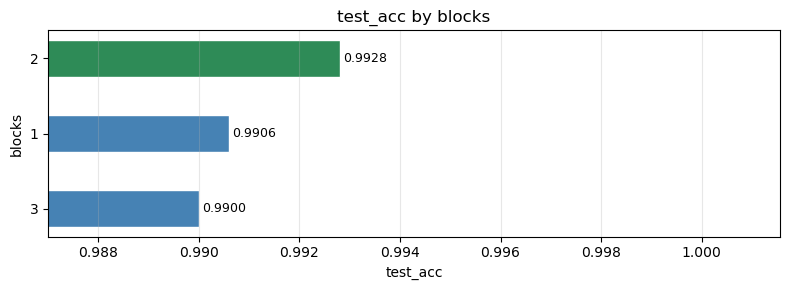


→ Beste Blockanzahl: 2 (Accuracy: 0.9928), Verbesserung zu Baseline %: 0.75%)


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,epochs,add_dropout,dropout_rate,blocks,early_stop,model_name
0,Architecture,Augmentiert,0.028993,0.9906,9,4,64,20,False,0.0,1,True,model_Architecture_Augmentiert_batch_64_epochs...
1,Architecture,Augmentiert,0.025114,0.9928,9,4,64,20,False,0.0,2,True,model_Architecture_Augmentiert_batch_64_epochs...
2,Architecture,Augmentiert,0.035454,0.9900,14,9,64,20,False,0.0,3,True,model_Architecture_Augmentiert_batch_64_epochs...


In [14]:
phase3_results = pd.concat(
    [
        train_and_evaluate_models(
            {best_dataset: datasets[best_dataset]},
            method="Architecture", batch_size=best_batch_size, epochs=20, blocks=b, early_stop=True,
        )[0]
        for b in [1, 2, 3]
    ],
    ignore_index=True,
)

plot_metric_distribution_by_group(
    phase3_results, metric_col="test_acc", group_col="blocks",
    ylim=(phase3_results["test_acc"].min() - 0.003, 1.0),
)

best_blocks = int(phase3_results.loc[phase3_results["test_acc"].idxmax(), "blocks"])
best_blocks_acc = phase3_results["test_acc"].max()
print(f"\n→ Beste Blockanzahl: {best_blocks} (Accuracy: {best_blocks_acc:.4f}), Verbesserung zu Baseline %: {(best_blocks_acc - baseline_acc) / baseline_acc * 100:.2f}%)")
phase3_results

---

# Phase 4 – Beste Regularisierung finden (Dropout)

Verwendet werden die beste Datenvariante, die beste Batch-Größe und die beste Blockanzahl aus den vorherigen Phasen.
Zuerst werden bei maximal 20 Epochen mit Early Stopping verschiedene Dropout-Raten von 0.1 bis 0.5 verglichen.


  Training: Augmentiert
  Training: Augmentiert
  Training: Augmentiert
  Training: Augmentiert
  Training: Augmentiert


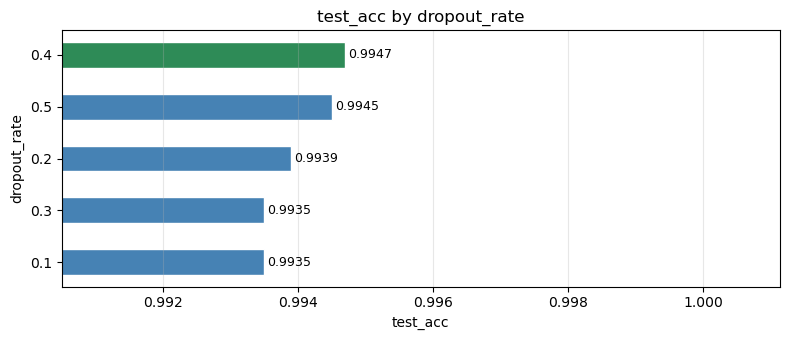


→ Beste Dropout-Rate: 0.4  (Accuracy: 0.9947, Verbesserung zu Baseline %: 0.94%)


,method,dataset,test_loss,test_acc,trained_epochs,best_epoch,batch_size,epochs,add_dropout,dropout_rate,blocks,early_stop,model_name
0,Dropout,Augmentiert,0.022383,0.9935,11,6,64,20,True,0.1,2,True,model_Dropout_Augmentiert_batch_64_epochs_20_b...
1,Dropout,Augmentiert,0.016944,0.9939,10,5,64,20,True,0.2,2,True,model_Dropout_Augmentiert_batch_64_epochs_20_b...
2,Dropout,Augmentiert,0.021520,0.9935,11,6,64,20,True,0.3,2,True,model_Dropout_Augmentiert_batch_64_epochs_20_b...
3,Dropout,Augmentiert,0.016002,0.9947,10,5,64,20,True,0.4,2,True,model_Dropout_Augmentiert_batch_64_epochs_20_b...
4,Dropout,Augmentiert,0.020797,0.9945,11,6,64,20,True,0.5,2,True,model_Dropout_Augmentiert_batch_64_epochs_20_b...


In [15]:
phase4_parts = []

for rate in [0.1, 0.2, 0.3, 0.4, 0.5]:
    df, _ = train_and_evaluate_models(
        {best_dataset: datasets[best_dataset]},
        method="Dropout", batch_size=best_batch_size, epochs=20,
        add_dropout=True, dropout_rate=rate, blocks=best_blocks, early_stop=True,
    )
    phase4_parts.append(df)

phase4_results = pd.concat(phase4_parts, ignore_index=True)

plot_metric_distribution_by_group(
    phase4_results, metric_col="test_acc", group_col="dropout_rate",
    ylim=(phase4_results["test_acc"].min() - 0.003, 1.0),
)

best_row = phase4_results.loc[phase4_results["test_acc"].idxmax()]
best_dropout_rate = float(best_row["dropout_rate"])
best_dropout_acc = best_row["test_acc"]
print(f"\n→ Beste Dropout-Rate: {best_dropout_rate}  (Accuracy: {best_dropout_acc:.4f}, Verbesserung zu Baseline %: {(best_dropout_acc - baseline_acc) / baseline_acc * 100:.2f}%)")
phase4_results

In [16]:
best_model_name = best_row["model_name"]
best_model_path = os.path.join(checkpoint_dir, best_model_name)
best_model = keras.models.load_model(best_model_path)
best_model.summary()
best_model.save("best_model.keras")
print(f"Bestes Modell gespeichert unter: {best_model_path}")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 64)                1

---

# Phase 5 – Bestes Modell inspizieren und mit der Baseline vergleichen

Zum Abschluss wird das beste gefundene Modell der ursprünglichen Baseline direkt gegenübergestellt.
Verglichen werden Testgenauigkeit, Verlust, trainierte Epochen, Parameteranzahl und Vorhersagen auf Beispielbildern.
So wird sichtbar, ob die zusätzliche Modellkomplexität tatsächlich zu einem nachvollziehbaren Leistungsgewinn führt.


In [17]:
baseline_row = baseline_results.iloc[0].copy()

if "best_row" in globals():
    selected_best_row = best_row.copy()
elif "phase4_results" in globals():
    selected_best_row = phase4_results.loc[phase4_results["test_acc"].idxmax()].copy()
else:
    raise ValueError("Kein bestes Modell gefunden. Fuehre zuerst die vorherigen Phasen aus.")

baseline_model_path = os.path.join(checkpoint_dir, baseline_row["model_name"])
selected_best_model_path = os.path.join(checkpoint_dir, selected_best_row["model_name"])

baseline_model = keras.models.load_model(baseline_model_path)
selected_best_model = keras.models.load_model(selected_best_model_path)

comparison_df = pd.DataFrame(
    [
        {
            "Modell": "Baseline",
            "Datensatz": baseline_row["dataset"],
            "Bloecke": int(baseline_row["blocks"]),
            "Dropout": float(baseline_row["dropout_rate"]),
            "Batch Size": int(baseline_row["batch_size"]),
            "Trainierte Epochen": int(baseline_row["trained_epochs"]),
            "Test Loss": float(baseline_row["test_loss"]),
            "Test Accuracy": float(baseline_row["test_acc"]),
            "Parameter": int(baseline_model.count_params()),
        },
        {
            "Modell": "Bestes Modell",
            "Datensatz": selected_best_row["dataset"],
            "Bloecke": int(selected_best_row["blocks"]),
            "Dropout": float(selected_best_row["dropout_rate"]),
            "Batch Size": int(selected_best_row["batch_size"]),
            "Trainierte Epochen": int(selected_best_row["trained_epochs"]),
            "Test Loss": float(selected_best_row["test_loss"]),
            "Test Accuracy": float(selected_best_row["test_acc"]),
            "Parameter": int(selected_best_model.count_params()),
        },
    ]
 )

accuracy_gain_abs = comparison_df.iloc[1]["Test Accuracy"] - comparison_df.iloc[0]["Test Accuracy"]
accuracy_gain_rel = accuracy_gain_abs / comparison_df.iloc[0]["Test Accuracy"] * 100
loss_delta = comparison_df.iloc[1]["Test Loss"] - comparison_df.iloc[0]["Test Loss"]

print("Vergleich Baseline vs. bestes Modell:\n")
print(comparison_df.to_string(index=False))
print()
print(f"Absolute Accuracy-Verbesserung: {accuracy_gain_abs:.4f}")
print(f"Relative Accuracy-Verbesserung: {accuracy_gain_rel:.2f}%")
print(f"Differenz Test Loss: {loss_delta:.4f}")

print("\nBaseline-Modell:")
baseline_model.summary()

print("\nBestes Modell:")
selected_best_model.summary()

Vergleich Baseline vs. bestes Modell:

       Modell   Datensatz  Bloecke  Dropout  Batch Size  Trainierte Epochen  Test Loss  Test Accuracy  Parameter
     Baseline Unverändert        1      0.0          32                  10   0.045705         0.9854     347146
Bestes Modell Augmentiert        2      0.4          64                  10   0.016002         0.9947     121930

Absolute Accuracy-Verbesserung: 0.0093
Relative Accuracy-Verbesserung: 0.94%
Differenz Test Loss: -0.0297

Baseline-Modell:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatt

Die folgenden Heatmaps vergleichen direkt, wie gut Baseline und bestes Modell die einzelnen Ziffern erkennen. Zusätzlich zeigt eine Differenz-Heatmap, bei welchen echten Ziffern sich die Erkennungsrate verbessert oder verschlechtert hat.


/tmp/ipykernel_15122/2702686042.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap(base_cmap_name, 256)


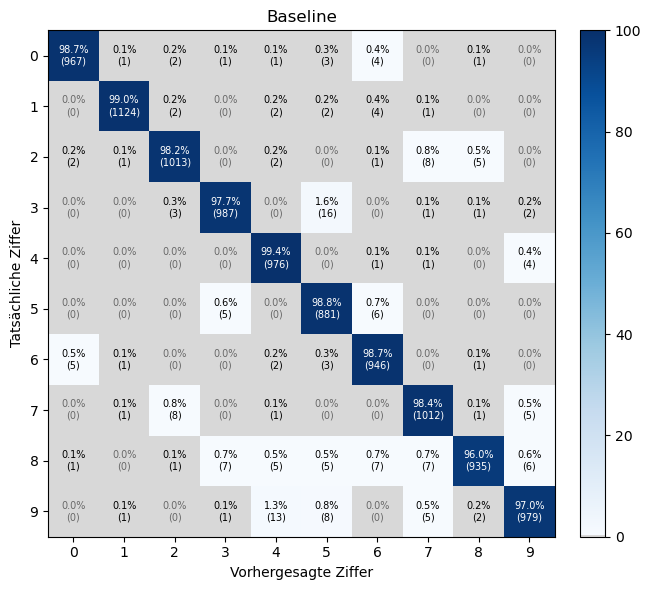

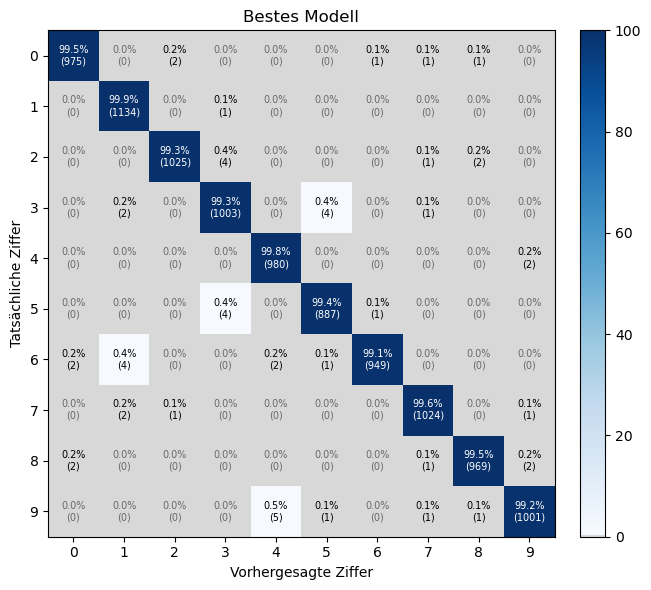

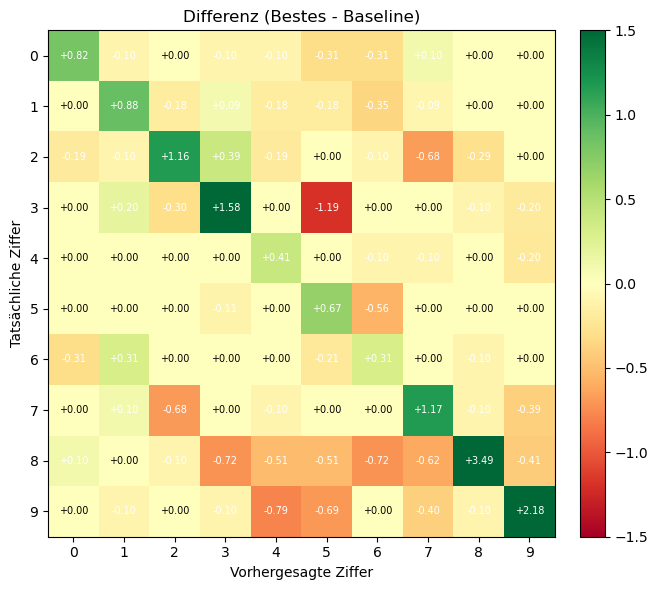

Erkennungsrate pro Ziffer im Vergleich:
Ziffer 0: Baseline 98.67% | Bestes Modell 99.49% | Delta +0.82 Prozentpunkte
Ziffer 1: Baseline 99.03% | Bestes Modell 99.91% | Delta +0.88 Prozentpunkte
Ziffer 2: Baseline 98.16% | Bestes Modell 99.32% | Delta +1.16 Prozentpunkte
Ziffer 3: Baseline 97.72% | Bestes Modell 99.31% | Delta +1.58 Prozentpunkte
Ziffer 4: Baseline 99.39% | Bestes Modell 99.80% | Delta +0.41 Prozentpunkte
Ziffer 5: Baseline 98.77% | Bestes Modell 99.44% | Delta +0.67 Prozentpunkte
Ziffer 6: Baseline 98.75% | Bestes Modell 99.06% | Delta +0.31 Prozentpunkte
Ziffer 7: Baseline 98.44% | Bestes Modell 99.61% | Delta +1.17 Prozentpunkte
Ziffer 8: Baseline 96.00% | Bestes Modell 99.49% | Delta +3.49 Prozentpunkte
Ziffer 9: Baseline 97.03% | Bestes Modell 99.21% | Delta +2.18 Prozentpunkte


In [18]:

checkpoint_dir = "checkpoints"


_, (x_test, y_test) = keras.datasets.mnist.load_data()

normalized_0_1_x_test  = x_test.astype("float32") / 255.0

aug_normalized_0_1_x_test  = normalized_0_1_x_test

datasets = {
    "Baseline": (_, _, normalized_0_1_x_test, y_test),
    "Bestes Modell": (_, _, aug_normalized_0_1_x_test, y_test),
}

baseline_model_path = os.path.join(checkpoint_dir, "model_Baseline_Unverändert.keras")
selected_best_model_path = os.path.join(checkpoint_dir, "best_model.keras")

baseline_model = keras.models.load_model(baseline_model_path)
selected_best_model = keras.models.load_model(selected_best_model_path)

def compute_confusion_percent(model, x_data, y_data):
    probabilities = model.predict(x_data, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    counts = tf.math.confusion_matrix(y_data, predictions, num_classes=10).numpy()
    percent = counts / counts.sum(axis=1, keepdims=True) * 100
    return counts, percent

def make_zero_gray_cmap(base_cmap_name="Blues"):
    base = plt.cm.get_cmap(base_cmap_name, 256)
    colors = base(np.linspace(0, 1, 256))
    colors[0] = [0.85, 0.85, 0.85, 1.0]
    return ListedColormap(colors)

def plot_heatmap(values, counts, title, cmap, vmin, vmax, digits, is_difference=False):
    fig, ax = plt.subplots(figsize=(7, 6))

    image = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(digits)
    ax.set_yticks(digits)
    ax.set_xticklabels(digits)
    ax.set_yticklabels(digits)
    ax.set_xlabel("Vorhergesagte Ziffer")
    ax.set_ylabel("Tatsächliche Ziffer")
    ax.set_title(title)

    threshold = (vmin + vmax) / 2

    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            value = values[row, col]

            if is_difference:
                label = f"{value:+.2f}"
                text_color = "white" if abs(value) > abs(threshold) else "black"
            else:
                label = f"{value:.1f}%\n({counts[row, col]})"
                if np.isclose(value, 0.0):
                    text_color = "dimgray"
                else:
                    text_color = "white" if value > threshold else "black"

            ax.text(
                col,
                row,
                label,
                ha="center",
                va="center",
                color=text_color,
                fontsize=7,
            )

    plt.tight_layout()
    plt.show()


baseline_x_test = datasets["Baseline"][2]
baseline_y_test = datasets["Baseline"][3]
best_x_test = datasets["Bestes Modell"][2]
best_y_test = datasets["Bestes Modell"][3]

baseline_counts, baseline_percent = compute_confusion_percent(
    baseline_model, baseline_x_test, baseline_y_test
)
best_counts, best_percent = compute_confusion_percent(
    selected_best_model, best_x_test, best_y_test
)
difference_percent = best_percent - baseline_percent

digits = np.arange(10)

# Colormap mit grauem 0%-Wert
blues_with_gray_zero = make_zero_gray_cmap("Blues")

# Einzelne Plots
plot_heatmap(
    baseline_percent,
    baseline_counts,
    "Baseline",
    blues_with_gray_zero,
    0,
    100,
    digits,
    is_difference=False,
)

plot_heatmap(
    best_percent,
    best_counts,
    "Bestes Modell",
    blues_with_gray_zero,
    0,
    100,
    digits,
    is_difference=False,
)

plot_heatmap(
    difference_percent,
    None,
    "Differenz (Bestes - Baseline)",
    "RdYlGn",
    -1.5,
    1.5,
    digits,
    is_difference=True,
)

baseline_class_accuracy = np.diag(baseline_counts) / baseline_counts.sum(axis=1) * 100
best_class_accuracy = np.diag(best_counts) / best_counts.sum(axis=1) * 100
class_accuracy_delta = best_class_accuracy - baseline_class_accuracy

print("Erkennungsrate pro Ziffer im Vergleich:")
for digit, baseline_accuracy, best_accuracy, delta in zip(
    digits, baseline_class_accuracy, best_class_accuracy, class_accuracy_delta
):
    print(
        f"Ziffer {digit}: Baseline {baseline_accuracy:.2f}% | "
        f"Bestes Modell {best_accuracy:.2f}% | Delta {delta:+.2f} Prozentpunkte"
    )

## Vergleich mit Modellen aus der Vorlesung


In [19]:
lecture_results = {}

data = load_digits()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0, stratify=y
)

def evaluate_sklearn(name, clf, x_tr, y_tr, x_te, y_te):
    clf.fit(x_tr, y_tr)

    print(f"{name} Testgenauigkeit: {clf.score(x_te, y_te):.4f}")

    lecture_results[f"Vorlesung: {name}"] = clf.score(x_te, y_te)


evaluate_sklearn(
    "Perceptron",
    Perceptron(tol=None, eta0=0.001, max_iter=10000, random_state=42),
    x_train,
    y_train,
    x_test,
    y_test,
)

evaluate_sklearn(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=8, random_state=42),
    x_train,
    y_train,
    x_test,
    y_test,
)

evaluate_sklearn(
    "kNN",
    KNeighborsClassifier(n_neighbors=27),
    x_train,
    y_train,
    x_test,
    y_test,
)

evaluate_sklearn(
    "SVM", SVC(probability=True, random_state=42), x_train, y_train, x_test, y_test
)

evaluate_sklearn(
    "Logistic Regression",
    LogisticRegression(random_state=42),
    x_train,
    y_train,
    x_test,
    y_test,
)

evaluate_sklearn(
    "Random Forest",
    RandomForestClassifier(n_estimators=1000, random_state=42),
    x_train,
    y_train,
    x_test,
    y_test,
)

clf1 = RandomForestClassifier(n_estimators=1000, random_state=42)
clf2 = KNeighborsClassifier(n_neighbors=27)
clf3 = SVC(probability=True, random_state=42)
clf4 = LogisticRegression(random_state=42)
estimators = [("tree", clf1), ("kNN", clf2), ("SVM", clf3), ("LR", clf4)]

evaluate_sklearn(
    "Soft Voting Ensemble",
    VotingClassifier(estimators=estimators, voting="soft"),
    x_train,
    y_train,
    x_test,
    y_test,
)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

def create_simple_dropout_model():
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    x = keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        name="conv_1"
        )(inputs)

    x = keras.layers.MaxPooling2D(
        pool_size=(3, 3),
        name="maxpool_1"
        )(x)

    x = keras.layers.Flatten(name="flatten")(x)

    x = keras.layers.Dropout(
        rate=0.5,
        name="dropout"
        )(x)

    x = keras.layers.Dense(
        units=64,
        activation="relu",
        name="dense_1"
        )(x)

    outputs = keras.layers.Dense(
        units=10,
        activation="softmax",
        name="output"
        )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="simple_cnn_dropout"
        )

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        )

    return model


model_drop_full = create_simple_dropout_model()

model_drop_full.fit(
    x_train, y_train, batch_size=64, epochs=10, validation_split=0.2
)
test_loss, test_acc = model_drop_full.evaluate(x_test, y_test)

print(f"Vorlesung CNN Testgenauigkeit: {test_acc:.4f}")
print(f"Eigenes CNN Testgenauigkeit: {selected_best_row['test_acc']:.4f}")

Perceptron Testgenauigkeit: 0.9333
Decision Tree Testgenauigkeit: 0.8472
kNN Testgenauigkeit: 0.9306
SVM Testgenauigkeit: 0.9861
Logistic Regression Testgenauigkeit: 0.9667
Random Forest Testgenauigkeit: 0.9750
Soft Voting Ensemble Testgenauigkeit: 0.9806
Epoch 1/10
750/750 [==============================] - 6s 8ms/step - loss: 0.3582 - accuracy: 0.8919 - val_loss: 0.1196 - val_accuracy: 0.9663
Epoch 2/10
750/750 [==============================] - 4s 6ms/step - loss: 0.1454 - accuracy: 0.9553 - val_loss: 0.0872 - val_accuracy: 0.9739
Epoch 3/10
750/750 [==============================] - 6s 8ms/step - loss: 0.1095 - accuracy: 0.9662 - val_loss: 0.0690 - val_accuracy: 0.9800
Epoch 4/10
750/750 [==============================] - 10s 14ms/step - loss: 0.0896 - accuracy: 0.9720 - val_loss: 0.0584 - val_accuracy: 0.9828
Epoch 5/10
750/750 [==============================] - 8s 11ms/step - loss: 0.0791 - accuracy: 0.9751 - val_loss: 0.0625 - val_accuracy: 0.9820
Epoch 6/10
750/750 [===========

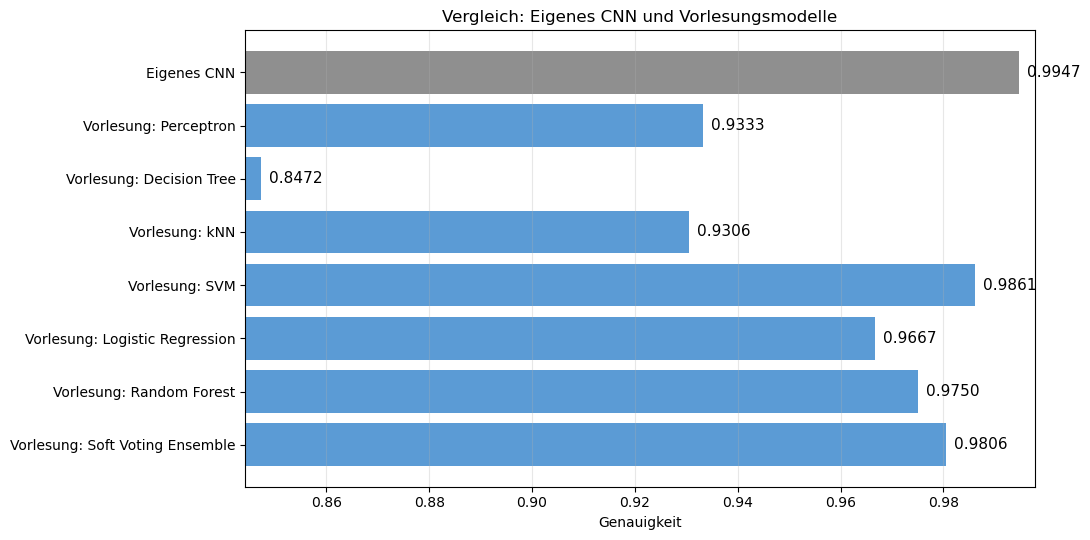

(<Figure size 1100x550 with 1 Axes>,
 <Axes: title={'center': 'Vergleich: Eigenes CNN und Vorlesungsmodelle'}, xlabel='Genauigkeit'>)

In [20]:
def plot_summary(
    results_1,
    results_2,
    title
):
    single_plot_results = {name: float(acc) for name, acc in results_1.items()}
    ensemble_plot_results = {name: float(acc) for name, acc in results_2.items()}

    comparison_results = {**single_plot_results, **ensemble_plot_results}
    labels = list(comparison_results.keys())
    values = np.array(list(comparison_results.values()))
    colors = ["#8f8f8f"] * len(single_plot_results) + ["#5b9bd5"] * len(ensemble_plot_results)

    avg_single_models = float(np.mean(list(single_plot_results.values())))
    avg_ensembles = float(np.mean(list(ensemble_plot_results.values())))

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bars = ax.barh(labels, values, color=colors)

    x_min = max(0.0, values.min() - 0.003)
    x_max = min(1.0, values.max() + 0.003)
    ax.set_xlim(x_min, x_max)
    ax.invert_yaxis()

    for bar, value in zip(bars, values):
        ax.text(
            value + (x_max - x_min) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            ha="left",
            fontsize=11,
        )


    fig.subplots_adjust(bottom=0.22)


    ax.set_xlabel("Genauigkeit")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return fig, ax


plot_summary({"Eigenes CNN": selected_best_row['test_acc']}, lecture_results, "Vergleich: Eigenes CNN und Vorlesungsmodelle")